In [1]:
import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
import shapely as shp
import hvplot.pandas
import matplotlib.pyplot as plt
import matplotlib.colors
import folium
import pint

ureg = pint.UnitRegistry()
ureg.setup_matplotlib(True)


In [2]:
ais_gdf = gpd.read_file('../data/ais.gpkg')

In [3]:
# check properties of the relevant variables
# here you might want to check for missing values and extreme values
# this dataset already seems to be cleaned up. 
ais_gdf[['SOG', 'COG']].describe()

,SOG,COG
count,84699.000000,84202.000000
mean,3.064408,171.512940
std,5.839462,117.313857
min,0.000000,0.000000
25%,0.000000,56.400000
50%,0.000000,191.000000
75%,4.500000,275.800000
max,43.300000,359.900000


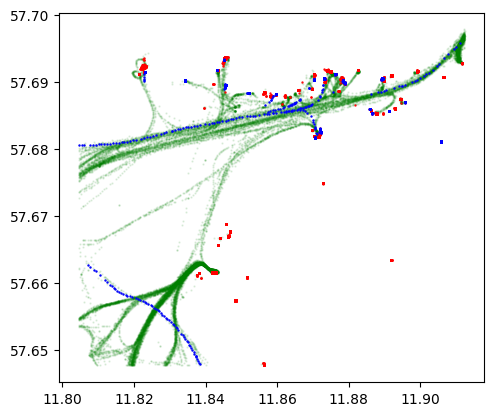

In [4]:
# Check if all zero speed over ground ships (red) are in a port
# They are all in the port or inland. So we can ignore them. 
fig, ax = plt.subplots()
ais_gdf[ais_gdf['SOG'] != 0].plot(color='green', ax=ax, alpha=0.1, markersize=0.5)
ais_gdf[ais_gdf['SOG'] == 0].plot(color='red', ax=ax, alpha=0.9, markersize=0.5)
# ships that are moored are not always moored, so let's ignore that
ais_gdf[ais_gdf['NavStatus'] == 'Moored'].plot(color='blue', ax=ax, markersize=0.5)
# filter and make a copy (because we'll add columns later)
ais_gdf = ais_gdf[ais_gdf['SOG'] > 0].copy()

<Axes: >

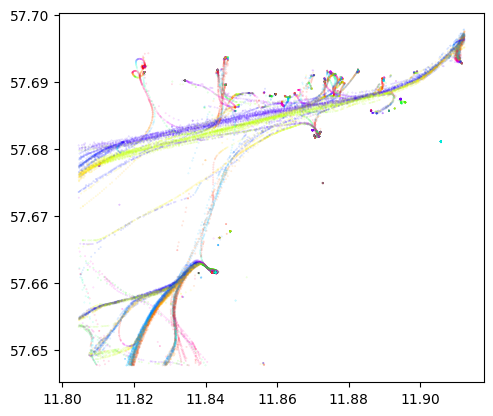

In [5]:
# Check if course over ground is consistent
N = matplotlib.colors.Normalize(0, 360)
cog = ais_gdf['COG']
cm = matplotlib.cm.hsv
rgba = cm(N(cog))
ais_gdf.plot(c=rgba, markersize=0.1, alpha=0.2)

In [6]:
# Time is in a local format. 
# Let's convert it to normal times
ais_gdf["t"] = pd.to_datetime(ais_gdf["Timestamp"], format="%d/%m/%Y %H:%M:%S")
ais_gdf['traj_id'] = ais_gdf['MMSI']
ais_gdf['obj_id'] = ais_gdf['MMSI']
traj_collection = mpd.TrajectoryCollection(
    ais_gdf.set_index('t'), 
    traj_id_col="traj_id", 
    obj_id_col="obj_id",
    min_length=100
)
traj_collection.add_speed(overwrite=True, units=('m', 's'))
traj_collection.add_direction(overwrite=True)


TrajectoryCollection with 77 trajectories

In [7]:
# sample trajectory to make sure we use correct angles
# deg2rad - 0 north -> 0 east

In [8]:
traj_collection.to_point_gdf().to_parquet('ais.parquet')
traj_collection.to_line_gdf().to_parquet('ais-line.parquet')

(0.0, 20.0)

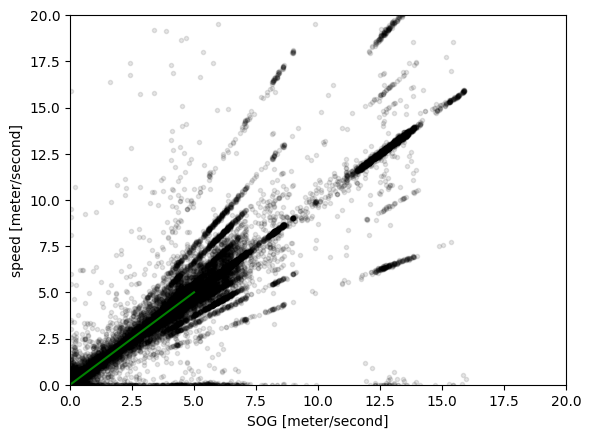

In [9]:
point_gdf = traj_collection.to_point_gdf()

sog = point_gdf['SOG'].values * ureg.knot
speed = point_gdf['speed'].values * (ureg.meter / ureg.second)

fig, ax = plt.subplots()
# units will be filled into the labels
ax.plot(sog.to('meter / second'), speed, 'k.', alpha=0.1)
ax.plot([0, 5], [0, 5], 'g-')
ax.set_xlabel(f"SOG [{ax.get_xlabel()}]")
ax.set_ylabel(f"speed [{ax.get_ylabel()}]")
ax.set_xlim(0, 20)
ax.set_ylim(0, 20)





Text(0, 0.5, 'direction [degree]')

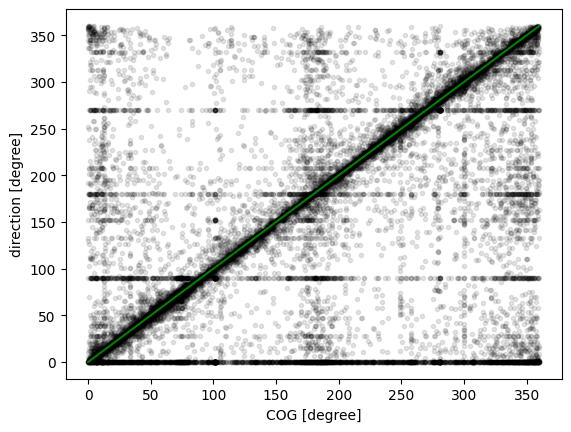

In [10]:
cog = point_gdf['COG'].values * ureg.degree
direction = point_gdf['direction'].values * ureg.degree

fig, ax = plt.subplots()
ax.plot(cog, direction, 'k.', alpha=0.1)
ax.plot([0, 360], [0, 360], 'g-')

ax.set_xlabel(f"COG [{ax.get_xlabel()}]")
ax.set_ylabel(f"direction [{ax.get_ylabel()}]")


In [11]:
# get the trajectory of these two ship
# 230957000
# 210035000

# ships were closest at around 17:45


# these ships were closest around 19:06
mmsi_a = 265550210
mmsi_b = 265410000

traj_a = traj_collection.get_trajectory(mmsi_a)
traj_b = traj_collection.get_trajectory(mmsi_b)
# traj_a
# traj_b
print(traj_a)

Trajectory 265550210 (2017-07-05 08:54:34 to 2017-07-05 19:27:25) | Size: 764 | Length: 15712.5m
Bounds: (11.805392, 57.647893, 11.882855, 57.693732)
LINESTRING (11.805392 57.676007, 11.805997 57.676248, 11.806605 57.676488, 11.807282 57.676748, 11.8


In [12]:
traj_collection_ab = mpd.TrajectoryCollection([traj_a, traj_b])

In [13]:
traj_collection_ab.hvplot()

:Overlay
   .WMTS.I    :WMTS   [Longitude,Latitude]
   .Path.I    :Path   [Longitude,Latitude]
   .Path.II   :Path   [Longitude,Latitude]
   .Points.I  :Points   [Longitude,Latitude]   (triangle_angle)
   .Points.II :Points   [Longitude,Latitude]   (triangle_angle)

<Axes: >

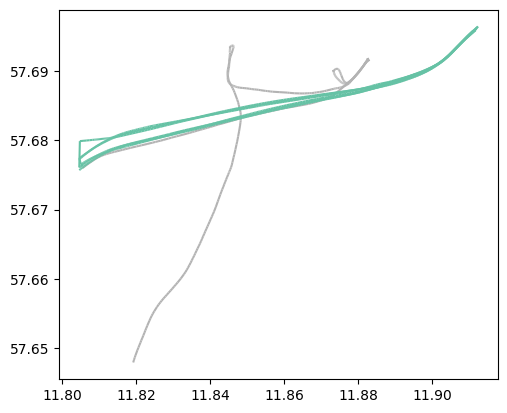

In [14]:
fig, ax = plt.subplots()
traj_collection_ab.plot(ax=ax, column='MMSI', cmap='Set2')

/Users/baart_f/.virtualenvs/py312/lib/python3.12/site-packages/pandas/core/construction.py:630: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/Users/baart_f/.virtualenvs/py312/lib/python3.12/site-packages/pandas/core/construction.py:630: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


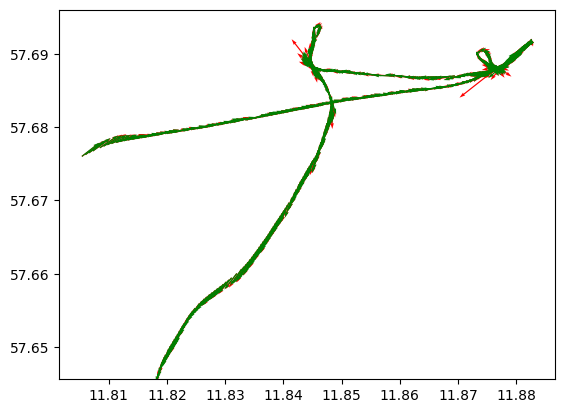

In [44]:
df = traj_a.df.copy()

df['traj_u'] = np.cos(np.deg2rad(- df['direction'] + 90)) * df['speed']
df['traj_v'] = np.sin(np.deg2rad(- df['direction'] + 90)) * df['speed']

df['traj_og_u'] = np.sin(np.deg2rad(df['COG'])) * (df['SOG'].values * ureg.knot).to(ureg.meter_per_second)
df['traj_og_v'] = np.cos(np.deg2rad(df['COG'])) * (df['SOG'].values * ureg.knot).to(ureg.meter_per_second)


df['x'] = df['geometry'].x
df['y'] = df['geometry'].y

fig, ax =  plt.subplots()
ax.quiver(df['x'], df['y'], df['traj_u'], df['traj_v'], color='r')
ax.quiver(df['x'], df['y'], df['traj_og_u'], df['traj_og_v'], color='g')



In [47]:
deg = [0, 90, 180, 270]
rad = [0.5 * np.pi, 0, -0.5 *np.pi, -np.pi]

np.sin(np.deg2rad(deg)), np.cos(rad)
np.cos(np.deg2rad(deg)), np.sin(rad)


(array([ 1.0000000e+00,  6.1232340e-17, -1.0000000e+00, -1.8369702e-16]),
 array([ 1.0000000e+00,  0.0000000e+00, -1.0000000e+00, -1.2246468e-16]))

In [20]:
ax.set_xlim(11.84, 11.85)
import geopandas as gpd
import pandas as pd
from movingpandas import Trajectory
from datetime import datetime, timedelta
import numpy as np
from shapely.geometry import Point

def calculate_velocity(df):
    # TODO: check if this corresponds to x, y
    df['velocity_x'] = df['sog'] * np.sin(np.deg2rad(df['cog']))
    df['velocity_y'] = df['sog'] * np.cos(np.deg2rad(df['cog']))
    return df

def calculate_cpa_tcpa(traj1, traj2):
    df1 = calculate_velocity(traj1.df)
    df2 = calculate_velocity(traj2.df)
    
    # Extract positions and velocities
    pos1 = np.array(list(df1['geometry'].apply(lambda p: (p.x, p.y))))
    pos2 = np.array(list(df2['geometry'].apply(lambda p: (p.x, p.y))))
    vel1 = np.array(df1[['velocity_x', 'velocity_y']])
    vel2 = np.array(df2[['velocity_x', 'velocity_y']])
    timestamps1 = df1['timestamp'].values
    timestamps2 = df2['timestamp'].values
    
    # Calculate relative positions and velocities
    rel_pos = pos1[:, None, :] - pos2[None, :, :]
    rel_vel = vel1[:, None, :] - vel2[None, :, :]
    
    # Calculate time to CPA (tcpa) for each combination
    dot_rel_pos_vel = np.einsum('ijk,ijk->ij', rel_pos, rel_vel)
    dot_rel_vel = np.einsum('ijk,ijk->ij', rel_vel, rel_vel)
    tcpa_matrix = -dot_rel_pos_vel / dot_rel_vel
    
    # Mask invalid tcpa values (negative tcpa values)
    valid_mask = tcpa_matrix >= 0
    valid_tcpa = np.where(valid_mask, tcpa_matrix, np.inf)
    
    # Find the minimum tcpa and corresponding indices
    min_tcpa_idx = np.unravel_index(np.argmin(valid_tcpa), valid_tcpa.shape)
    min_tcpa = valid_tcpa[min_tcpa_idx]
    
    # Calculate the CPA position based on minimum tcpa
    cpa_pos1 = pos1[min_tcpa_idx[0]] + vel1[min_tcpa_idx[0]] * min_tcpa
    cpa_pos2 = pos2[min_tcpa_idx[1]] + vel2[min_tcpa_idx[1]] * min_tcpa
    cpa_distance = np.linalg.norm(cpa_pos1 - cpa_pos2)
    
    # Determine CPA time
    cpa_time1 = timestamps1[min_tcpa_idx[0]]
    cpa_time2 = timestamps2[min_tcpa_idx[1]]
    cpa_time = min(cpa_time1 + timedelta(seconds=min_tcpa), cpa_time2 + timedelta(seconds=min_tcpa))

    return cpa_distance, cpa_time, min_tcpa

# Sample data
data1 = {'timestamp': [datetime(2025, 1, 12, 10, 0, 0), datetime(2025, 1, 12, 11, 0, 0)], 
         'geometry': [Point(4.899, 52.37), Point(4.900, 52.38)],
         'sog': [10, 10], 'cog': [0, 0]}
data2 = {'timestamp': [datetime(2025, 1, 12, 10, 30, 0), datetime(2025, 1, 12, 11, 30, 0)], 
         'geometry': [Point(4.8995, 52.375), Point(4.901, 52.39)],
         'sog': [12, 12], 'cog': [90, 90]}

# Create GeoDataFrames
gdf1 = gpd.GeoDataFrame(data1, crs="EPSG:4326")
gdf2 = gpd.GeoDataFrame(data2, crs="EPSG:4326")

# Create Trajectories
traj1 = Trajectory(gdf1, traj_id=1)
traj2 = Trajectory(gdf2, traj_id=2)

# Calculate CPA and TCPA
cpa, cpa_time, tcpa = calculate_cpa_tcpa(traj1, traj2)

print(f"CPA: {cpa}, CPA Time: {cpa_time}, TCPA: {tcpa} seconds")
traj_a.df

,Timestamp,MMSI,NavStatus,SOG,COG,Name,ShipType,geometry,traj_id,obj_id,speed,direction
t,,,,,,,,,,,,
2017-07-05 08:54:34,05/07/2017 08:54:34,265550210,Unknown value,8.8,51.8,TANKSKAR,Tanker,POINT (11.80539 57.67601),265550210,265550210,4.498302,53.314167
2017-07-05 08:54:44,05/07/2017 08:54:44,265550210,Unknown value,8.7,53.9,TANKSKAR,Tanker,POINT (11.806 57.67625),265550210,265550210,4.498302,53.314167
2017-07-05 08:54:54,05/07/2017 08:54:54,265550210,Unknown value,8.7,53.7,TANKSKAR,Tanker,POINT (11.8066 57.67649),265550210,265550210,4.506044,53.563570
2017-07-05 08:55:05,05/07/2017 08:55:05,265550210,Unknown value,8.7,53.7,TANKSKAR,Tanker,POINT (11.80728 57.67675),265550210,265550210,4.518193,54.311848
2017-07-05 08:55:24,05/07/2017 08:55:24,265550210,Unknown value,8.8,56.3,TANKSKAR,Tanker,POINT (11.80847 57.67718),265550210,265550210,4.514037,55.825248
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-07-05 19:26:35,05/07/2017 19:26:35,265550210,Unknown value,8.1,201.3,TANKSKAR,Tanker,POINT (11.82025 57.64966),265550210,265550210,5.182408,202.070523
2017-07-05 19:26:55,05/07/2017 19:26:55,265550210,Unknown value,8.1,201.0,TANKSKAR,Tanker,POINT (11.81976 57.64895),265550210,265550210,4.248134,199.936104
2017-07-05 19:27:04,05/07/2017 19:27:04,265550210,Unknown value,8.2,197.4,TANKSKAR,Tanker,POINT (11.81955 57.64862),265550210,265550210,4.241672,199.521011


In [21]:
traj_b.df

,Timestamp,MMSI,NavStatus,SOG,COG,Name,ShipType,geometry,traj_id,obj_id,speed,direction
t,,,,,,,,,,,,
2017-07-05 00:49:58,05/07/2017 00:49:58,265410000,Under way using engine,16.7,50.5,STENA JUTLANDICA,Passenger,POINT (11.80454 57.6757),265410000,265410000,17.209431,50.584160
2017-07-05 00:49:59,05/07/2017 00:49:59,265410000,Under way using engine,16.7,50.6,STENA JUTLANDICA,Passenger,POINT (11.80477 57.6758),265410000,265410000,17.209431,50.584160
2017-07-05 00:50:02,05/07/2017 00:50:02,265410000,Under way using engine,16.7,50.8,STENA JUTLANDICA,Passenger,POINT (11.80499 57.6759),265410000,265410000,5.743931,51.122257
2017-07-05 00:50:04,05/07/2017 00:50:04,265410000,Under way using engine,16.7,51.1,STENA JUTLANDICA,Passenger,POINT (11.80522 57.676),265410000,265410000,8.662448,51.369701
2017-07-05 00:50:05,05/07/2017 00:50:05,265410000,Under way using engine,16.7,51.4,STENA JUTLANDICA,Passenger,POINT (11.80545 57.67609),265410000,265410000,17.098071,52.662079
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-07-05 19:13:47,05/07/2017 19:13:47,265410000,Under way using engine,16.2,231.2,STENA JUTLANDICA,Passenger,POINT (11.8056 57.67776),265410000,265410000,8.313990,230.429690
2017-07-05 19:13:49,05/07/2017 19:13:49,265410000,Under way using engine,16.2,230.8,STENA JUTLANDICA,Passenger,POINT (11.80539 57.67766),265410000,265410000,8.385309,229.842489
2017-07-05 19:13:51,05/07/2017 19:13:51,265410000,Under way using engine,16.2,230.6,STENA JUTLANDICA,Passenger,POINT (11.80518 57.67756),265410000,265410000,8.375949,229.288122


# Searching for encounters
The next step is to find [encounters](https://www.transnav.eu/Article2_30_van%20Iperen,33,555.html). Van Iperen defined encounters as pairs of ships
- with a speed of at least 1 knot
- close to each other within 3 nautical miles within 20 minutes, based on their speed and course.




In [227]:
# Create all trajectories
trajs = mpd.TrajectoryCollection(ais_gdf, traj_id_col='MMSI', t='t')

# if we have observations to close to eachother, drop them, 
trajs = mpd.MinTimeDeltaGeneralizer(trajs).generalize(
    tolerance=datetime.timedelta(minutes=5)
)

# filter all the trajectories by speed
traj_dfs = []
for traj_i in trajs.trajectories:
    traj_df = traj_i.df[traj_i.df['SOG'] > 1]
    if traj_df.shape[0] < 2:
        continue
    traj_dfs.append(traj_df)

# recreate trajectory collection with filtered trajectories
trajs = mpd.TrajectoryCollection(
    pd.concat(traj_dfs),
    traj_id_col='MMSI'
)
trajs


TrajectoryCollection with 73 trajectories

# Project current speed and course
We have to project the current speed and speed and course for 20 minutes.


In [228]:
# let's look up one row of a trajectory
traj_i = trajs.trajectories[0]
traj_df = traj_i.df
row = traj_df.iloc[0]
row

Timestamp                            05/07/2017 17:32:18
MMSI                                           210035000
NavStatus                         Under way using engine
SOG                                                  9.8
COG                                                 52.8
Name                                      NORDIC HAMBURG
ShipType                                           Cargo
geometry     POINT (667244.4253610432 6396113.160745068)
t_min_t_0                                        -5262.0
Name: 2017-07-05 17:32:18, dtype: object

In [229]:
def project(row, d_t=datetime.timedelta(minutes=20)):
    d_t_s = d_t.total_seconds()
    direction_nautical_rad = np.deg2rad(row['COG'])
    # In nautical angles cos=y and sin=x, unlike mathematical angles
    d_y = np.cos(direction_nautical_rad) * (row['SOG'] / 0.5144) * d_t_s
    d_x = np.sin(direction_nautical_rad) * (row['SOG'] / 0.5144) * d_t_s
    p0 = row['geometry']
    p1 = shapely.affinity.translate(p0, xoff=d_x, yoff=d_y)
    vector = shapely.LineString([p0, p1])
    return pd.Series({
        "MMSI": row["MMSI"],
        "vector": vector,
        "t_0": row.name,
        "t_1": row.name + + d_t,
        "d_x": d_x,
        "d_y": d_y
    })


In [230]:
project(row)

MMSI                                              210035000
vector    LINESTRING (667244.4253610432 6396113.16074506...
t_0                                     2017-07-05 17:32:18
t_1                                     2017-07-05 17:52:18
d_x                                            18209.937473
d_y                                             13822.09485
dtype: object

<Axes: >

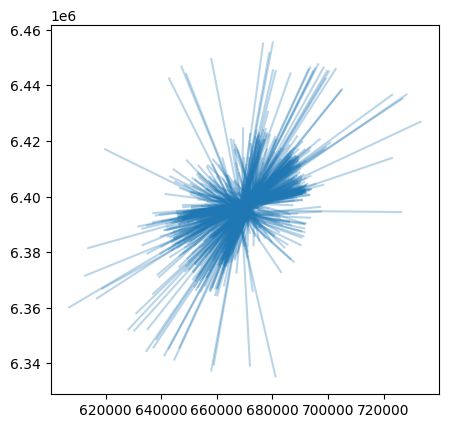

In [231]:
vectors = []
for traj_i in trajs.trajectories:
    traj_df = traj_i.df
    vectors_df_i = gpd.GeoDataFrame(traj_df.apply(project, axis=1), geometry='vector')
    vectors.append(vectors_df_i)
vectors_gdf = pd.concat(vectors)
vectors_gdf['vectorsaved']  = vectors_gdf['vector']

vectors_gdf.plot(alpha=0.3)

In [232]:
all_encounters = []
for mmsi, mmsi_df  in tqdm(vectors_gdf.groupby(['MMSI'])):

    # possible encounters (intersections, ignore time)
    encounters_gdf = gpd.sjoin(mmsi_df, vectors_gdf)
    
    # remove self joins and double joins
    encounters_gdf = encounters_gdf[encounters_gdf['MMSI_left'] > encounters_gdf['MMSI_right']]
    if not encounters_gdf.shape[0]:
        continue
        

    # create time intervals
    encounters_gdf['t_interval_left'] = encounters_gdf.apply(lambda row: pd.Interval(row['t_0_left'], row['t_1_left']), axis=1)
    encounters_gdf['t_interval_right'] = encounters_gdf.apply(lambda row: pd.Interval(row['t_0_right'], row['t_1_right']), axis=1)
    t_overlaps = encounters_gdf.apply(lambda row: row['t_interval_left'].overlaps(row['t_interval_right']), axis=1)
    # keep only temporal overlaps
    encounters_gdf = encounters_gdf[t_overlaps]

    # now we have  encounters as defined
    all_encounters.append(encounters_gdf)
all_encounters_gdf = gpd.GeoDataFrame(pd.concat(all_encounters))


  0%|          | 0/73 [00:00<?, ?it/s]

In [244]:
all_encounters_gdf[['MMSI_left', 'MMSI_right']].drop_duplicates()

,MMSI_left,MMSI_right
t_left,,
2017-07-05 01:02:19,219015425,219011922
2017-07-05 16:02:38,219015425,211748480
2017-07-05 17:44:49,219437000,210035000
2017-07-05 04:00:56,219554000,212636000
2017-07-05 16:30:36,219632000,211748480
...,...,...
2017-07-05 06:41:50,538002553,265609590
2017-07-05 06:41:50,538002553,231848000
2017-07-05 06:41:50,538002553,265525670


<Axes: >

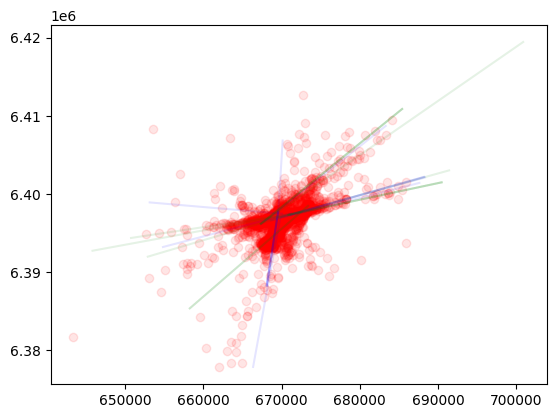

In [239]:
fig, ax = plt.subplots()
selected = all_encounters_gdf[
    (all_encounters_gdf['MMSI_left'] == mmsi_a) & 
    (all_encounters_gdf['MMSI_right'] == mmsi_b)
]
selected['vectorsaved_left'].plot(ax=ax, color='blue', alpha=0.1)
selected['vectorsaved_right'].plot(ax=ax, color='green', alpha=0.1)
selected['vectorsaved_left'].intersection(selected['vectorsaved_right']).plot(color='red', alpha=0.3, ax=ax)

all_encounters_gdf['vectorsaved_left'].intersection(all_encounters_gdf['vectorsaved_right']).plot(
    color='red', 
    alpha=0.1, 
    ax=ax
)